In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load dataset
df = pd.read_csv("superstore_final_dataset.csv", encoding="latin1")


# Inspect
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   str    
 2   Order_Date     9800 non-null   str    
 3   Ship_Date      9800 non-null   str    
 4   Ship_Mode      9800 non-null   str    
 5   Customer_ID    9800 non-null   str    
 6   Customer_Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product_ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub_Category   9800 non-null   str    
 16  Product_Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

,Row_ID,Postal_Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [4]:
# Shape of dataset
print("Rows:", df.shape[0], "Columns:", df.shape[1])

Rows: 9800 Columns: 18


In [5]:
# Show all column names
print(df.columns.tolist())

['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category', 'Product_Name', 'Sales']


<Axes: title={'center': 'Orders by Segment'}, xlabel='Segment'>

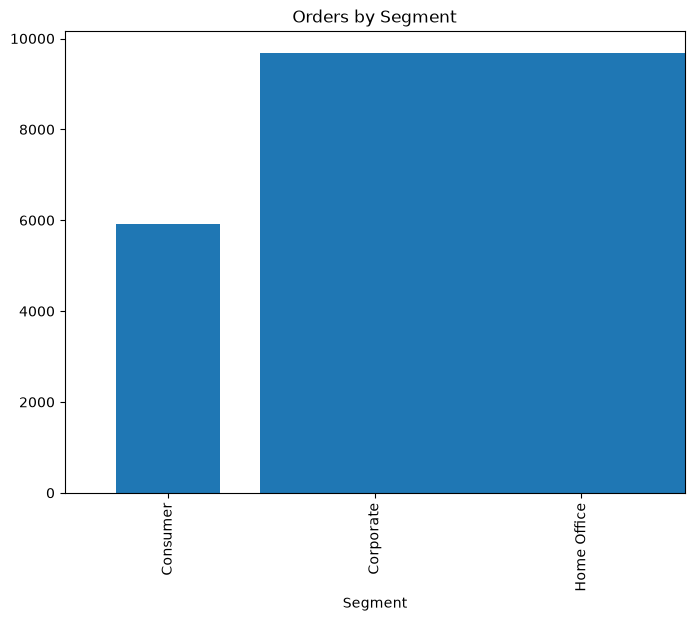

In [9]:
# Step 2: Univariate Analysis

# Numerical column: Sales
df[['Sales']].hist(figsize=(8,6))

# Categorical columns: Region, Category, Sub-Category, Segment
df['Region'].value_counts().plot(kind='bar', title="Orders by Region")
df['Category'].value_counts().plot(kind='bar', title="Orders by Category")
df['Sub_Category'].value_counts().plot(kind='bar', title="Orders by Sub-Category")
df['Segment'].value_counts().plot(kind='bar', title="Orders by Segment")


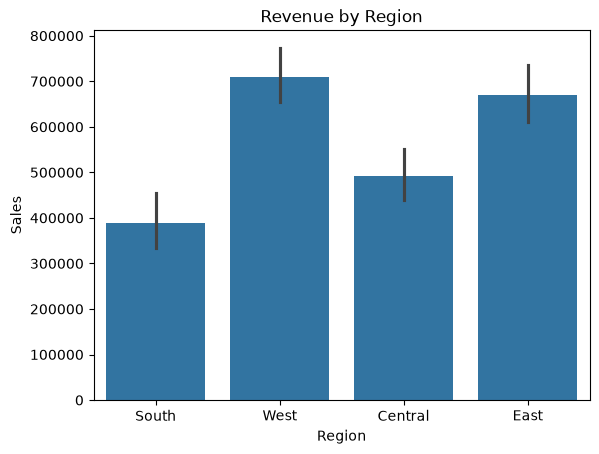

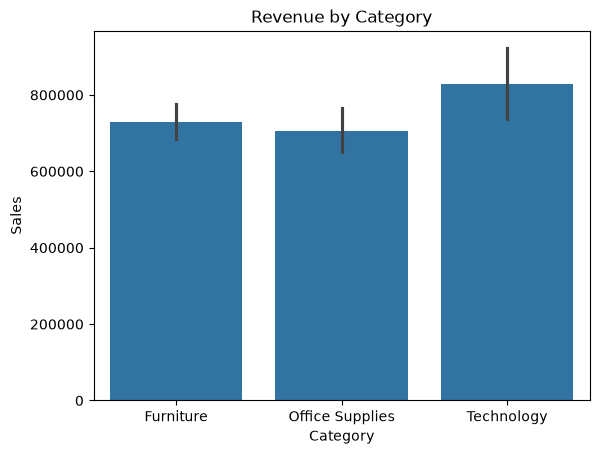

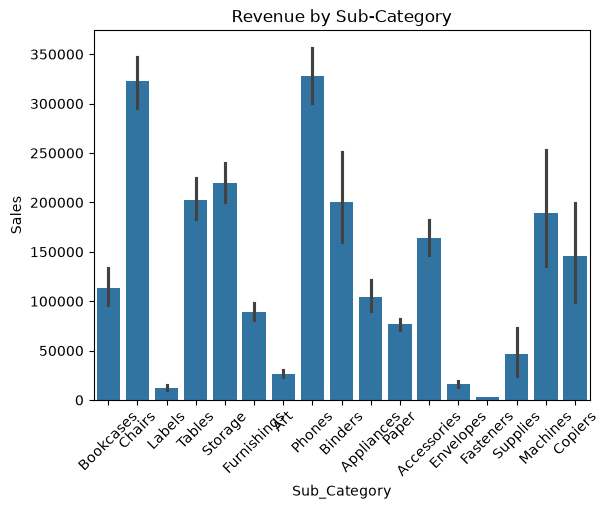

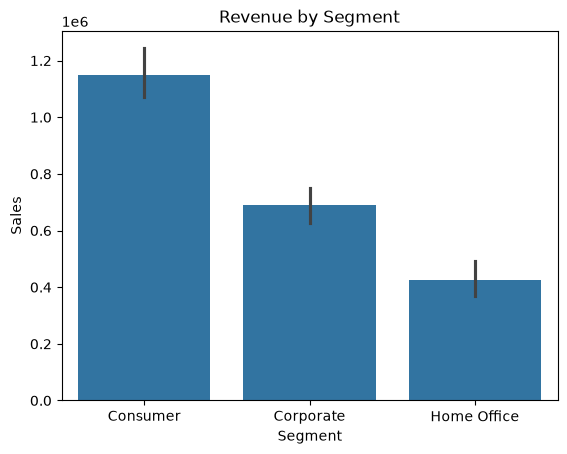

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 3: Bivariate Analysis

# Example: Sales vs another numerical column (if available)
# Since 'Profit' is not in your dataset, we'll skip that scatterplot.
# If you later add a Profit column, you can use:
# sns.scatterplot(x='Sales', y='Profit', data=df)

# Revenue (Sales) by Region
sns.barplot(x='Region', y='Sales', data=df, estimator=sum)
plt.title("Revenue by Region")
plt.show()

# Revenue (Sales) by Category
sns.barplot(x='Category', y='Sales', data=df, estimator=sum)
plt.title("Revenue by Category")
plt.show()

# Revenue (Sales) by Sub-Category
sns.barplot(x='Sub_Category', y='Sales', data=df, estimator=sum)
plt.title("Revenue by Sub-Category")
plt.xticks(rotation=45)
plt.show()

# Revenue (Sales) by Segment
sns.barplot(x='Segment', y='Sales', data=df, estimator=sum)
plt.title("Revenue by Segment")
plt.show()


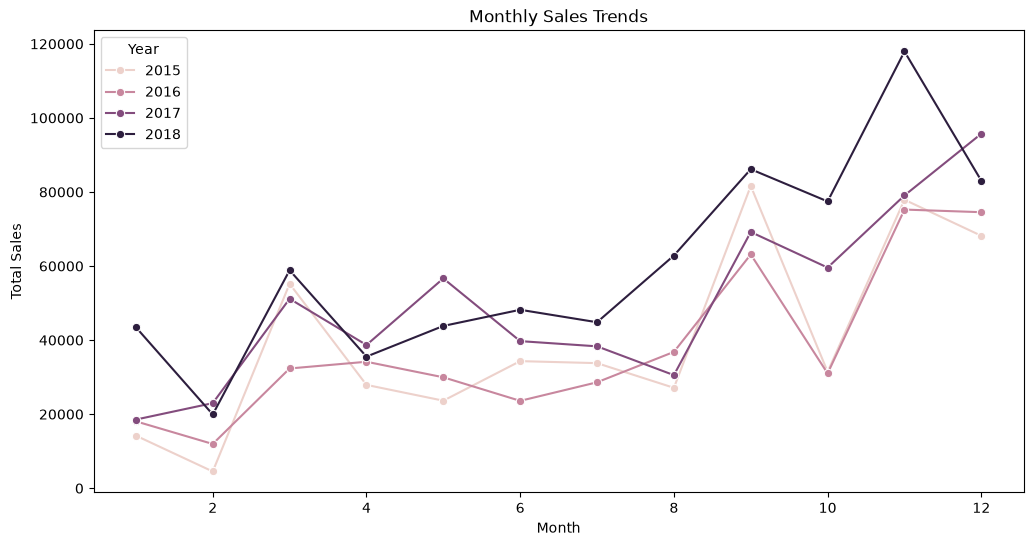

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 4: Time Series Exploration

# Convert Order_Date to datetime (dayfirst format)
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)

# Extract Year and Month
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month

# Group by Year and Month, then sum Sales
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

# Plot monthly sales trends
plt.figure(figsize=(12,6))
sns.lineplot(x='Month', y='Sales', hue='Year', data=monthly_sales, marker="o")
plt.title("Monthly Sales Trends")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()


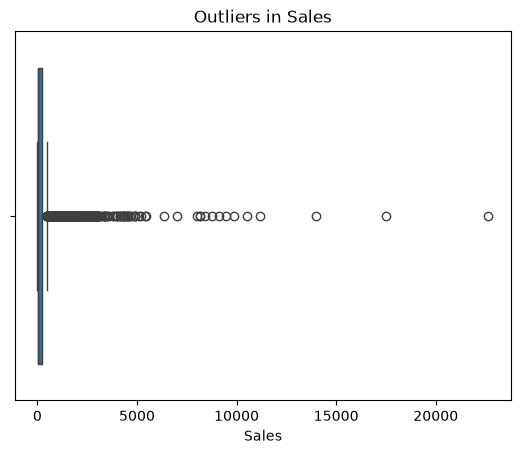

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 5: Outlier Detection

# Boxplot for Sales (to detect outliers in revenue values)
sns.boxplot(x=df['Sales'])
plt.title("Outliers in Sales")
plt.show()

In [2]:
import pandas as pd

# Step 6: Data Cleaning

# Load dataset first
df = pd.read_csv("superstore_final_dataset.csv", encoding="latin1")

# Remove duplicate rows
df = df.drop_duplicates()

# Handle missing values by filling with defaults
# Fill missing Sales values with 0
df = df.fillna({'Sales': 0})

In [3]:
# Step 7: KPI Calculations

# Total Revenue (sum of all Sales)
total_revenue = df['Sales'].sum()

# Average Order Value (average sales per order)
avg_order_value = df.groupby('Order_ID')['Sales'].sum().mean()

# Print KPI results
print("Total Revenue:", total_revenue)
print("Average Order Value:", avg_order_value)

Total Revenue: 2261536.7827
Average Order Value: 459.4751691791955


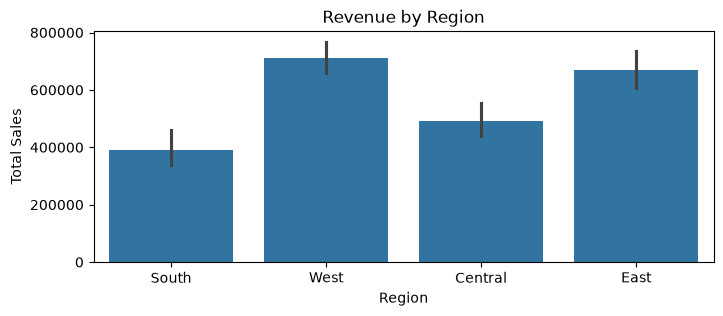

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 3: Visualizations

# Regional performance (Revenue by Region)
plt.figure(figsize=(8,3))
sns.barplot(x='Region', y='Sales', data=df, estimator=sum)
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

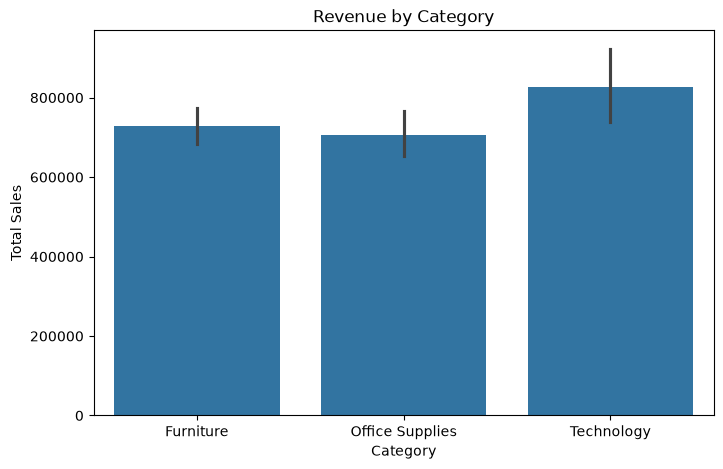

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 3: Visualizations - Category Trends

plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Sales', data=df, estimator=sum)
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

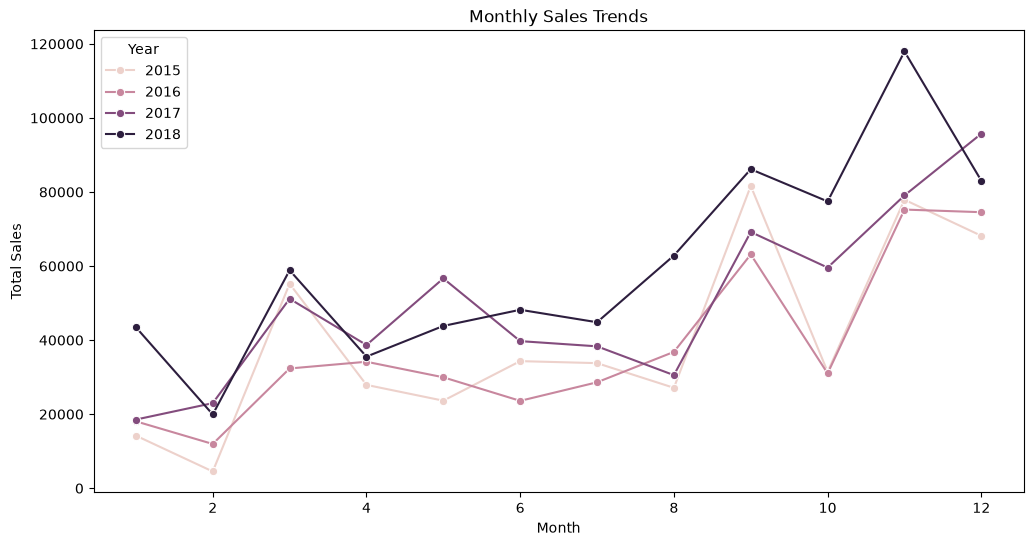

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Step 8: Seasonality Analysis

# Convert Order_Date to datetime (dayfirst format since your data is DD/MM/YYYY)
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)

# Extract Year and Month
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month

# Group by Year and Month, then sum Sales
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

# Plot monthly sales trends
plt.figure(figsize=(12,6))
sns.lineplot(x='Month', y='Sales', hue='Year', data=monthly_sales, marker="o")
plt.title("Monthly Sales Trends")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()


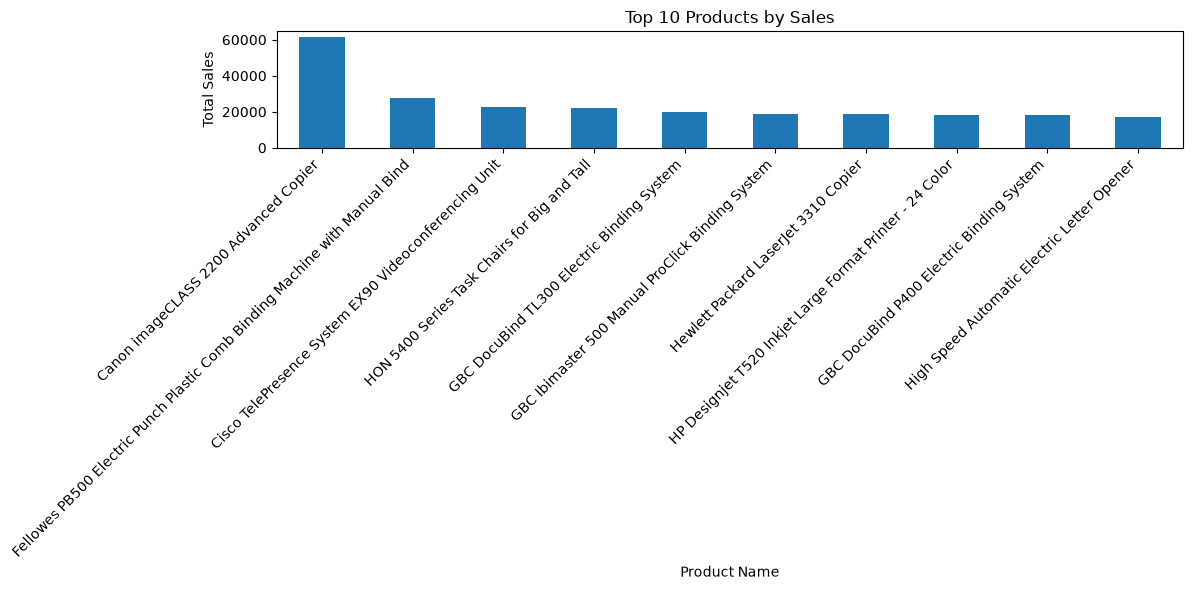

In [9]:
import matplotlib.pyplot as plt

# Step 9: Top Products Analysis (with aligned product names)

# Group by Product_Name and sum Sales, then take top 10
top_products = df.groupby('Product_Name')['Sales'].sum().nlargest(10)

# Plot top 10 products by Sales
top_products.plot(kind='bar', figsize=(12,6), title="Top 10 Products by Sales")

# Improve alignment of product names
plt.xlabel("Product Name")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha='right')  # rotate labels and align to the right
plt.tight_layout()                   # adjust layout to prevent cutoff
plt.show()


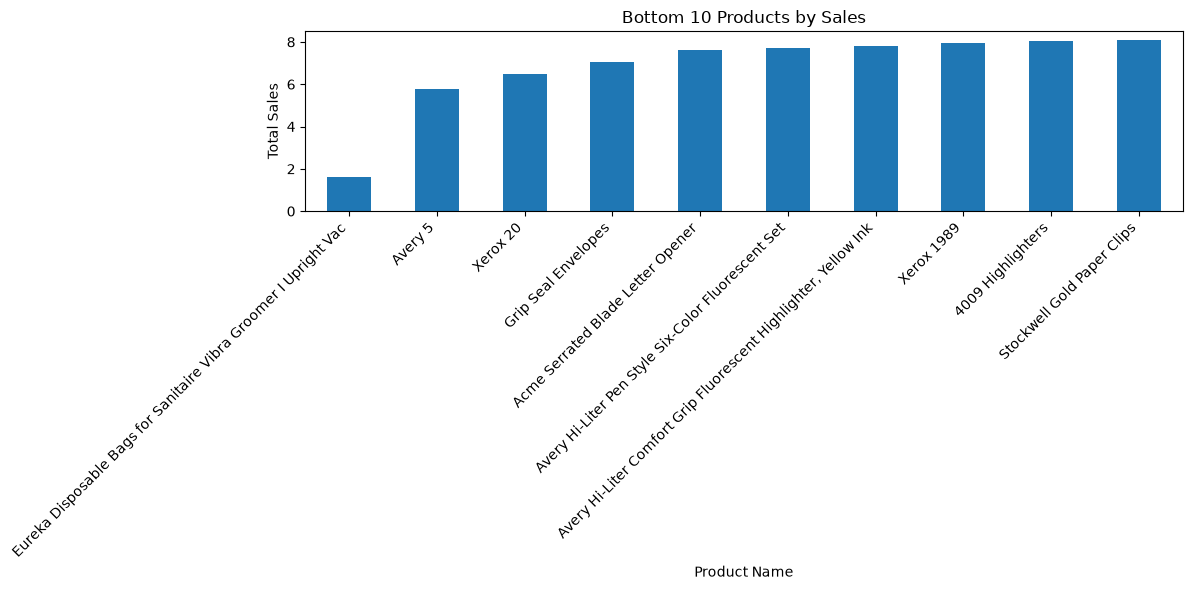

In [10]:
import matplotlib.pyplot as plt

# Step 10: Worst Products Analysis

# Group by Product_Name and sum Sales, then take bottom 10
worst_products = df.groupby('Product_Name')['Sales'].sum().nsmallest(10)

# Plot bottom 10 products by Sales
worst_products.plot(kind='bar', figsize=(12,6), title="Bottom 10 Products by Sales")

# Improve alignment of product names
plt.xlabel("Product Name")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha='right')  # rotate labels and align neatly
plt.tight_layout()                   # adjust layout to prevent cutoff
plt.show()


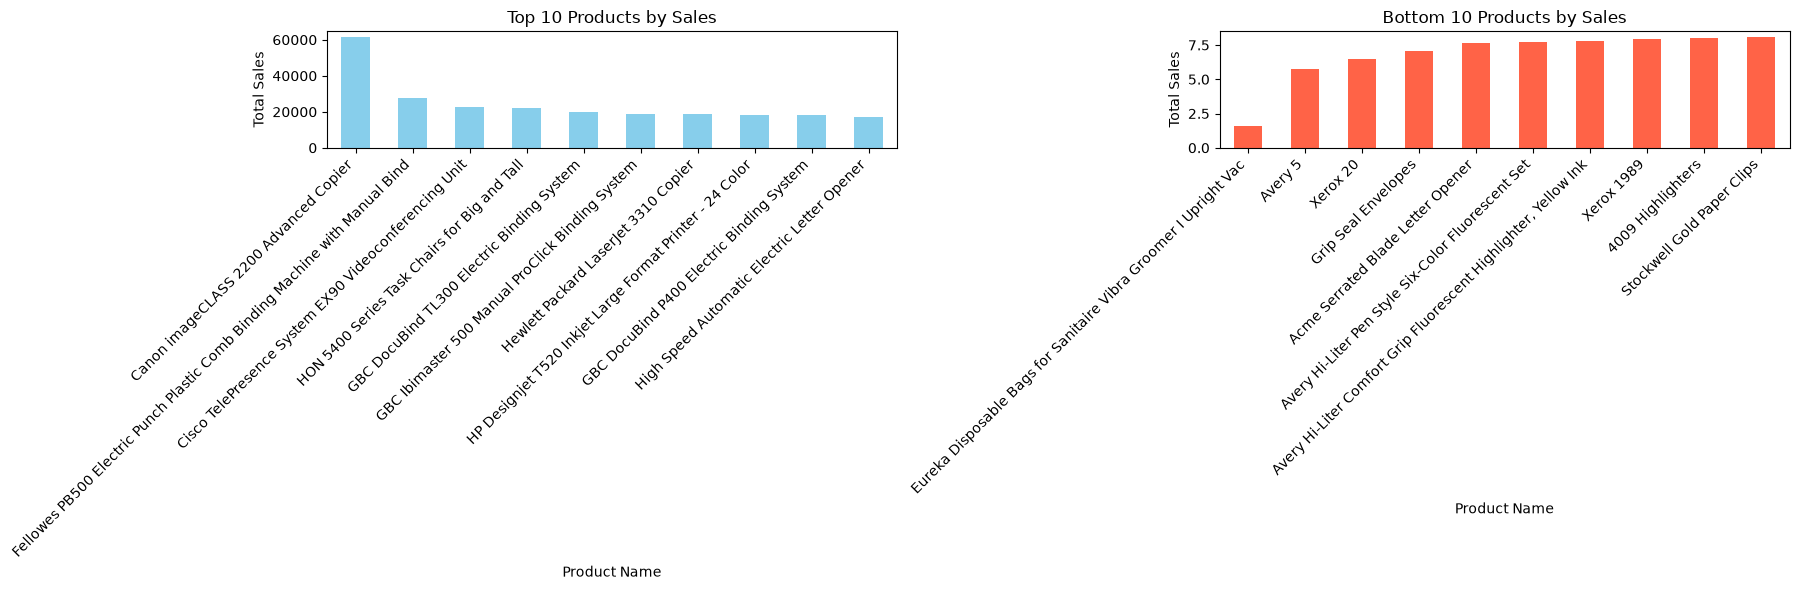

In [12]:
import matplotlib.pyplot as plt

# Step 11: Compare Top & Worst Products

# Top 10 products by Sales
top_products = df.groupby('Product_Name')['Sales'].sum().nlargest(10)

# Bottom 10 products by Sales
worst_products = df.groupby('Product_Name')['Sales'].sum().nsmallest(10)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18,6))

# Plot Top Products
top_products.plot(kind='bar', ax=axes[0], title="Top 10 Products by Sales", color='skyblue')
axes[0].set_xlabel("Product Name")
axes[0].set_ylabel("Total Sales")
axes[0].tick_params(axis='x', rotation=45)
for label in axes[0].get_xticklabels():
    label.set_horizontalalignment('right')

# Plot Worst Products
worst_products.plot(kind='bar', ax=axes[1], title="Bottom 10 Products by Sales", color='tomato')
axes[1].set_xlabel("Product Name")
axes[1].set_ylabel("Total Sales")
axes[1].tick_params(axis='x', rotation=45)
for label in axes[1].get_xticklabels():
    label.set_horizontalalignment('right')

plt.tight_layout()
plt.show()


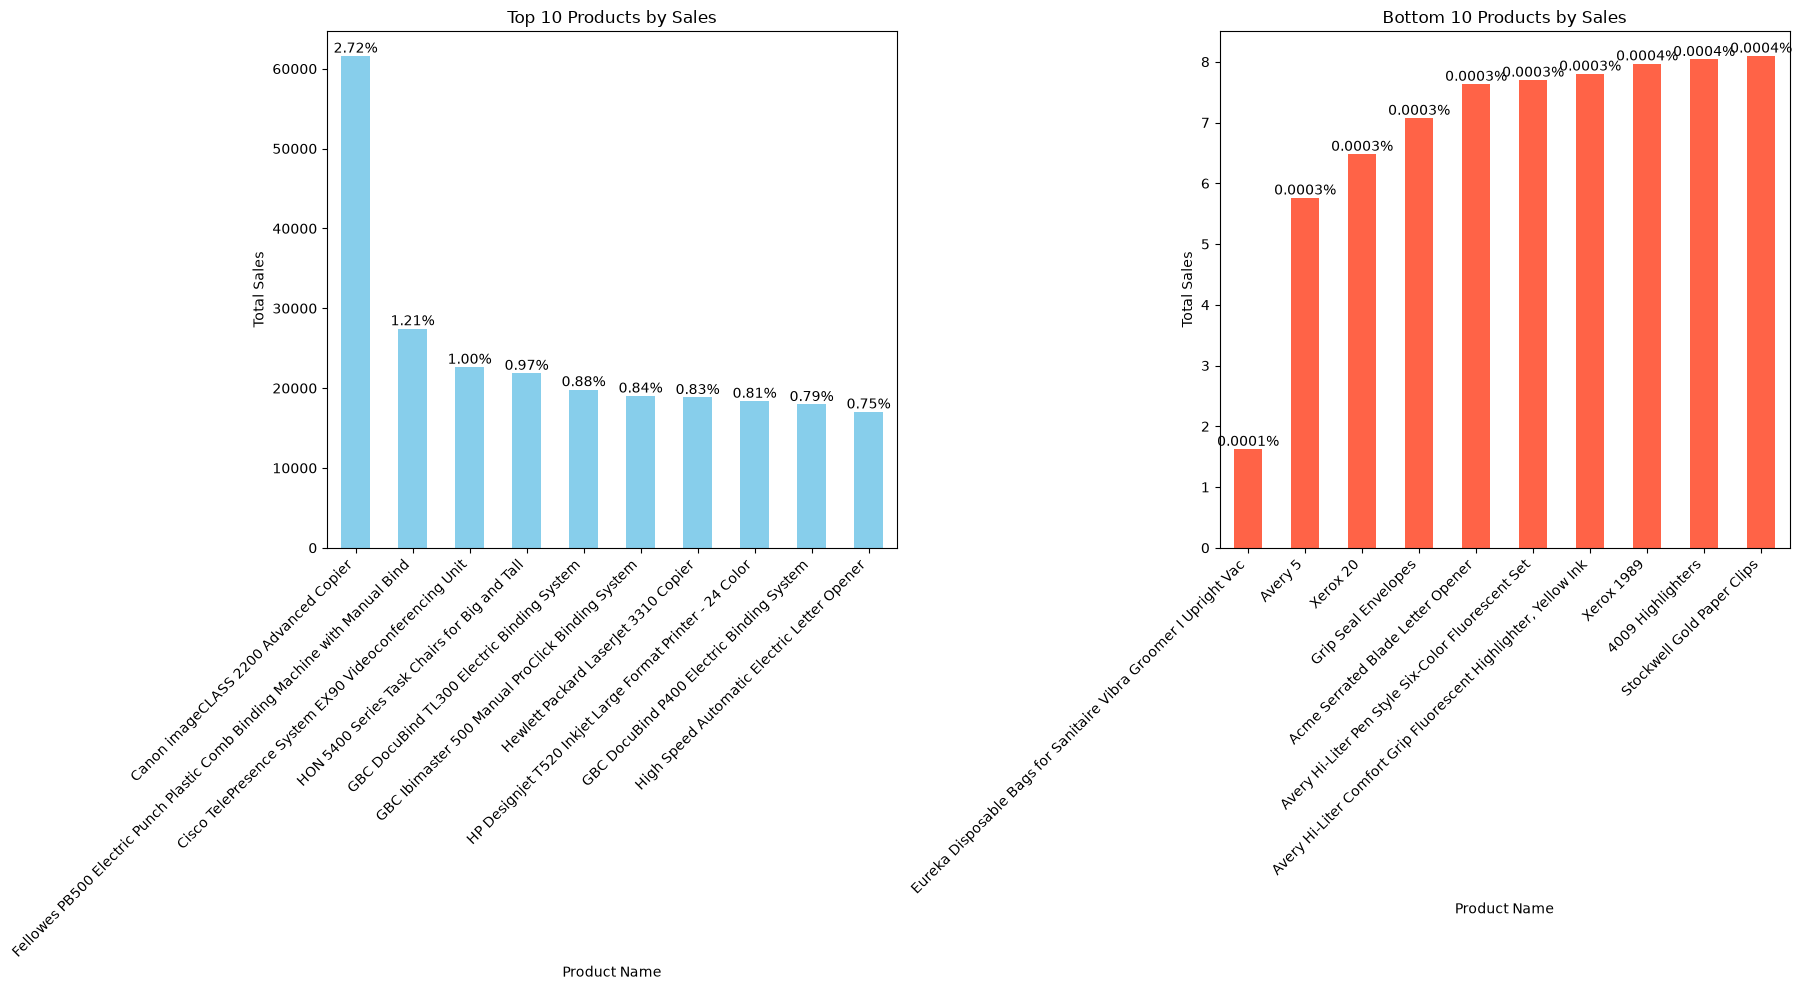

In [16]:
import matplotlib.pyplot as plt

# Step 12: Compare Top & Worst Products with % Contribution (taller graphs)

# Calculate total sales for percentage contribution
total_sales = df['Sales'].sum()

# Top 10 products by Sales
top_products = df.groupby('Product_Name')['Sales'].sum().nlargest(10)

# Bottom 10 products by Sales
worst_products = df.groupby('Product_Name')['Sales'].sum().nsmallest(10)

# Create subplots with increased height
fig, axes = plt.subplots(1, 2, figsize=(18,10))  # height increased from 6 to 10

# --- Top Products ---
top_products.plot(kind='bar', ax=axes[0], title="Top 10 Products by Sales", color='skyblue')
axes[0].set_xlabel("Product Name")
axes[0].set_ylabel("Total Sales")
axes[0].tick_params(axis='x', rotation=45)
for label in axes[0].get_xticklabels():
    label.set_horizontalalignment('right')

# Add percentage labels (Top Products)
for i, value in enumerate(top_products):
    percent = (value / total_sales) * 100
    axes[0].text(i, value, f"{percent:.2f}%", ha='center', va='bottom')

# --- Worst Products ---
worst_products.plot(kind='bar', ax=axes[1], title="Bottom 10 Products by Sales", color='tomato')
axes[1].set_xlabel("Product Name")
axes[1].set_ylabel("Total Sales")
axes[1].tick_params(axis='x', rotation=45)
for label in axes[1].get_xticklabels():
    label.set_horizontalalignment('right')

# Add percentage labels (Worst Products)
for i, value in enumerate(worst_products):
    percent = (value / total_sales) * 100
    axes[1].text(i, value, f"{percent:.4f}%", ha='center', va='bottom')  # more decimals for tiny contributions

plt.tight_layout()
plt.show()


In [18]:
!pip install openpyxl


  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   ---------------------------------------- 0/2 [et-xmlfile]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ----------------

In [19]:
# Export cleaned DataFrame to Excel
df.to_excel("cleaned_data.xlsx", index=False)


In [20]:
with pd.ExcelWriter("analysis_results.xlsx", engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Cleaned Data", index=False)
    top_products.to_excel(writer, sheet_name="Top Products")
    worst_products.to_excel(writer, sheet_name="Worst Products")
